## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/okayyysidd/trending-shows-dataset/trending_shows_dataset.csv")


## Data Exploration Functions

In [3]:
df.head(10)    # preview of first 10 rows

,title,year,imdb_id,tmdb_id,trakt_id,watchers
0,House of the Dragon,2022,tt11198330,94997,154574,9318
1,FROM,2022,tt9813792,124364,188205,7736
2,Rick and Morty,2013,tt2861424,60625,69829,5334
3,The Bear,2022,tt14452776,136315,189717,5175
4,Love Island USA,2019,tt8819906,90521,147958,2798
5,Avatar: The Last Airbender,2024,tt9018736,82452,136561,2710
6,I Will Find You,2026,tt34771210,278178,265319,2687
7,Widow's Bay,2026,tt33332385,270476,254678,2499
8,Dutton Ranch,2026,tt34991493,299167,296208,2456
9,The Agency,2024,tt26656917,219971,202341,2172


In [4]:
df.tail(10)          #preview of last 10 rows

,title,year,imdb_id,tmdb_id,trakt_id,watchers
614,Star Trek: Lower Decks,2020,tt9184820,85948,138641,50
615,RuPaul's Drag Race,2009,tt1353056,8514,8468,50
616,Bloodhounds,2023,tt26315487,127529,181431,50
617,Shetland,2013,tt2396135,46923,46647,50
618,Below Deck,2013,tt2342499,50042,49722,50
619,Gabby's Dollhouse,2021,tt9165438,111474,169028,50
620,The Legend of Kitchen Soldier,2026,tt38626513,295509,290708,50
621,EastEnders,1985,tt0088512,1871,1859,50
622,Tyler Perry’s Ruthless,2020,tt11306366,100575,158917,50
623,Password,2022,tt14671508,203254,195829,50


In [5]:
df.sample(5)          #preview of random 5 rows

,title,year,imdb_id,tmdb_id,trakt_id,watchers
601,Neon Genesis Evangelion,1995,tt0112159,890,885,51
326,All the Queen's Men,2021,tt14321632,133174,176512,98
2,Rick and Morty,2013,tt2861424,60625,69829,5334
126,FBI,2018,tt7491982,80748,133964,263
136,Frieren: Beyond Journey's End,2023,tt22248376,209867,198225,236


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624 entries, 0 to 623
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     624 non-null    object
 1   year      624 non-null    int64 
 2   imdb_id   621 non-null    object
 3   tmdb_id   624 non-null    int64 
 4   trakt_id  624 non-null    int64 
 5   watchers  624 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 29.4+ KB


In [7]:
df.isnull().sum()

title       0
year        0
imdb_id     3
tmdb_id     0
trakt_id    0
watchers    0
dtype: int64

In [8]:
df.describe()

,year,tmdb_id,trakt_id,watchers
count,624.000000,624.000000,624.000000,624.000000
mean,2015.323718,115583.003205,127793.466346,252.729167
std,10.767841,104858.792427,100962.884126,636.642819
min,1959.000000,45.000000,45.000000,50.000000
25%,2010.000000,17610.750000,17532.750000,69.000000
50%,2019.000000,81905.000000,136780.000000,102.000000
75%,2024.000000,220003.750000,202777.250000,206.250000
max,2026.000000,326568.000000,321341.000000,9318.000000


In [9]:
df.corr(numeric_only=True)

,year,tmdb_id,trakt_id,watchers
year,1.000000,0.783708,0.846167,0.051225
tmdb_id,0.783708,1.000000,0.964865,0.000552
trakt_id,0.846167,0.964865,1.000000,0.025741
watchers,0.051225,0.000552,0.025741,1.000000


In [10]:
df.nunique()

title       621
year         47
imdb_id     620
tmdb_id     623
trakt_id    623
watchers    274
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis - EDA

<Axes: xlabel='watchers', ylabel='title'>

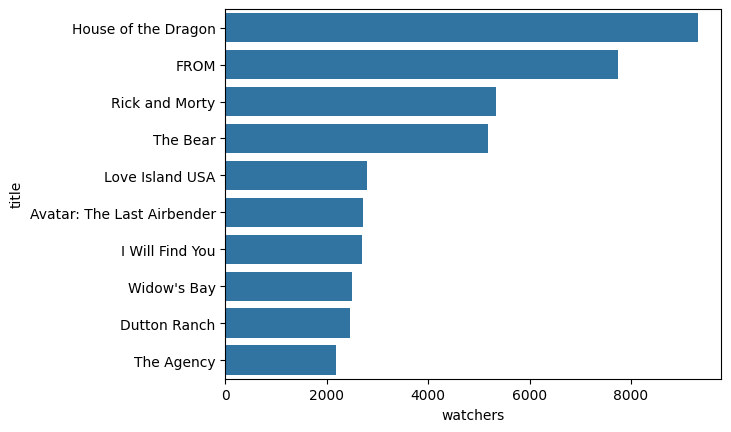

In [12]:
# Top watched shows 

top_shows = df.nlargest(10, "watchers")
sns.barplot(data=top_shows, x="watchers", y="title")

<Axes: xlabel='watchers'>

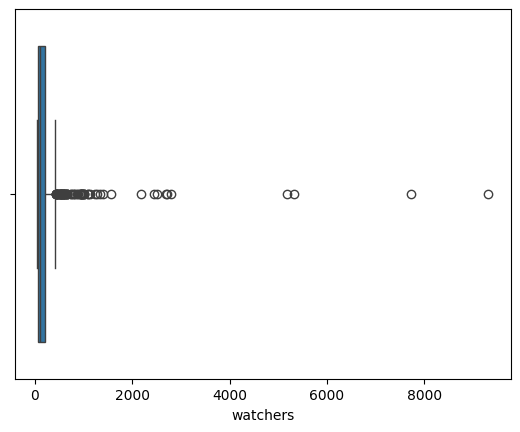

In [13]:
#Boxplot ditribution 

sns.boxplot(x=df["watchers"])

<Axes: xlabel='year', ylabel='Count'>

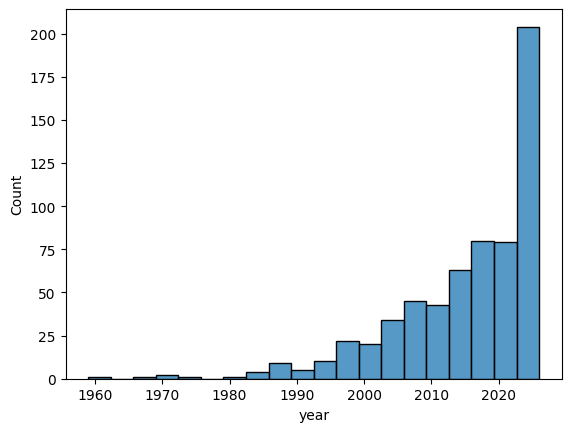

In [14]:
#Year distribution

sns.histplot(df["year"], bins=20)

<Axes: xlabel='watchers', ylabel='Count'>

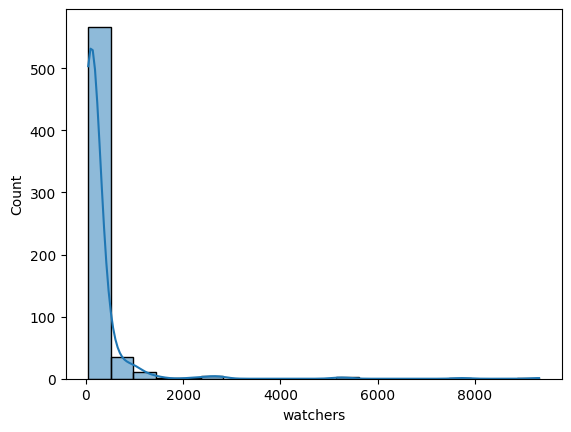

In [15]:
# Kde distribution 

sns.histplot(df["watchers"], kde=True,bins =20)


### Insight 
The watchers distribution is highly positively (right) skewed.

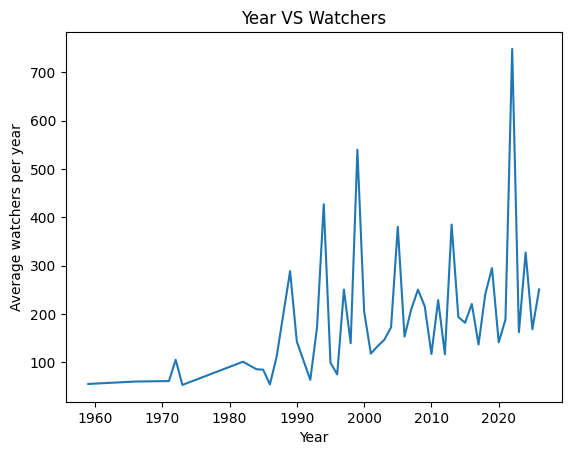

In [16]:
# Average Watchers Over Time

sns.lineplot(
    data=df.groupby("year", as_index=False)["watchers"].mean(),
    x="year",
    y="watchers"
)
plt.xlabel("Year")
plt.ylabel("Average watchers per year")
plt.title("Year VS Watchers")
plt.show()




### Insight

The average number of watchers generally increases over time but fluctuates considerably.

<Axes: >

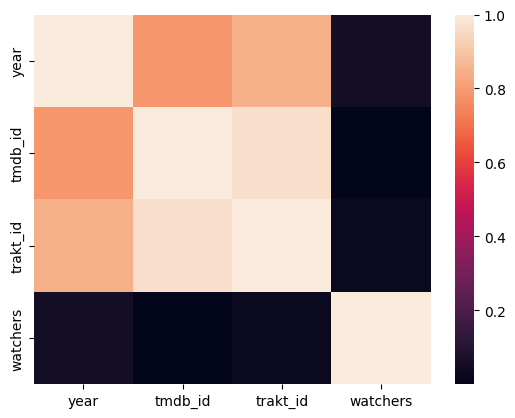

In [17]:
# Correlation Analysis 
sns.heatmap(df.corr(numeric_only=True))

### Insight 
tmdb_id and trakt_id show a strong positive correlation with year